In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print("TensorFlow version :", tf.__version__)
print("Keras version :", keras.__version__)

TensorFlow version : 2.21.0
Keras version : 3.15.0


In [2]:
from pathlib import Path

In [3]:
# Configuration des chemins
DATA_DIR = DATA_DIR = Path("../data/raw/images")

# Extensions d'images valides
EXTENSIONS_VALIDES = {'.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG'}

# Vérification des classes disponibles
classes = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])

print(f"Nombre de classes : {len(classes)}")
print(f"Classes détectées : {classes}")

# Comptage des images par classe
print("\nNombre d'images par classe :")
total = 0
for classe in classes:
    chemin = os.path.join(DATA_DIR, classe)
    nb_images = len([
        f for f in os.listdir(chemin)
        if os.path.splitext(f)[1] in EXTENSIONS_VALIDES
    ])
    total += nb_images
    print(f"  {classe} : {nb_images} images")

print(f"\nTotal : {total} images")

Nombre de classes : 6
Classes détectées : ['Kedjenou', 'alloco', 'foutou', 'mafe', 'thieboudiene', 'yassa-poulet']

Nombre d'images par classe :
  Kedjenou : 100 images
  alloco : 100 images
  foutou : 100 images
  mafe : 100 images
  thieboudiene : 100 images
  yassa-poulet : 100 images

Total : 600 images


In [4]:
# Voir tout le contenu du dossier en détail
for item in os.listdir(DATA_DIR):
    chemin_complet = os.path.join(DATA_DIR, item)
    type_item = "DOSSIER" if os.path.isdir(chemin_complet) else "FICHIER"
    print(f"{type_item} → {item}")

FICHIER → .gitkeep
DOSSIER → alloco
DOSSIER → foutou
DOSSIER → Kedjenou
DOSSIER → mafe
DOSSIER → thieboudiene
DOSSIER → yassa-poulet


In [5]:
# Chargement des données avec Keras
IMG_SIZE   = (224, 224)  # Taille requise par EfficientNet-B0
BATCH_SIZE = 32          # Nombre d'images traitées à la fois
SEED       = 42          # Pour avoir des résultats reproductibles

# 80% des images → entraînement
train_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# 20% des images → validation
val_ds = keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(f"Classes : {class_names}")
print(f"Images d'entraînement : {len(train_ds) * BATCH_SIZE}")
print(f"Images de validation  : {len(val_ds) * BATCH_SIZE}")

Found 600 files belonging to 6 classes.
Using 480 files for training.
Found 600 files belonging to 6 classes.
Using 120 files for validation.
Classes : ['Kedjenou', 'alloco', 'foutou', 'mafe', 'thieboudiene', 'yassa-poulet']
Images d'entraînement : 480
Images de validation  : 128


In [6]:
# ============================================================
# MODÈLE 1 : EfficientNet-B0
# ============================================================

In [7]:
# Construire le modèle EfficientNet-B0 

from tensorflow.keras import layers,models#un module de Keras qui contient toutes les briques de couches

# Augmentation de données (pour l'entraînement) ---
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

In [8]:
# Chargement du backbone EfficientNet-B0 pré-entraîné sur ImageNet

base_model_en = keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=IMG_SIZE + (3,),
    pooling="avg" 
)    

base_model_en.trainable = False # Geler le backbone dans un premier temps 


In [9]:
# Assemblage du modèle complet 

inputs = keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)

# normalisation interne (rescaling + normalisation ImageNet) s'en charge

x = keras.applications.efficientnet.preprocess_input(x)
 
x = base_model_en(x, training=False)  # training=False -> BatchNorm en mode inférence

In [10]:
# Tête de classification ---

x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model_en = keras.Model(inputs, outputs, name="efficientnet_b0_classifier")
 
model_en.summary()

Model: "efficientnet_b0_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [11]:
#  Compilation ---

model_en.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",  # labels entiers (pas one-hot)
    metrics=["accuracy"]
)
 
# Nombre de paramètres entraînables (tête uniquement, backbone gelé)
trainable_params = sum(
    tf.size(w).numpy() for w in model_en.trainable_weights
)
print(f"\nParamètres entraînables : {trainable_params:,}")


Paramètres entraînables : 329,478


In [12]:
# Entraînement Phase 1

# Callbacks pour optimiser l'entraînement
callbacks = [
    # S'arrête si la validation ne s'améliore plus après 5 epochs
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    # Réduit le learning rate si stagnation
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    )
]

# Lancement de l'entraînement
history = model_en.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=1
)

print("\nEntraînement terminé !")

Epoch 1/20


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


15/15 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.4625 - loss: 1.4120 - val_accuracy: 0.7917 - val_loss: 0.8613 - learning_rate: 0.0010
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.7812 - loss: 0.7014 - val_accuracy: 0.7917 - val_loss: 0.5917 - learning_rate: 0.0010
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8354 - loss: 0.4953 - val_accuracy: 0.8250 - val_loss: 0.5322 - learning_rate: 0.0010
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.8604 - loss: 0.4288 - val_accuracy: 0.8333 - val_loss: 0.4549 - learning_rate: 0.0010
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.8771 - loss: 0.3597 - val_accuracy: 0.8333 - val_loss: 0.4516 - learning_rate: 0.0010
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 26s 2s/step - accuracy: 0.9042 - loss: 0.2822 - val_accuracy: 0.8500 - val_loss: 0.4309 - learning_rate: 0.0010
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.9000 - loss: 0.2990 - val_accuracy: 0.8583 - va

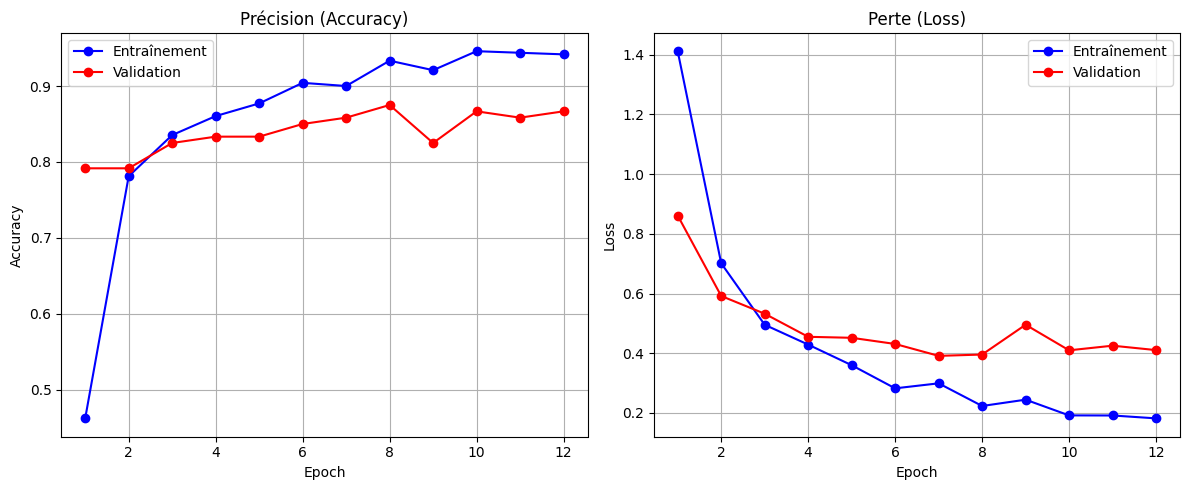

Courbes sauvegardées !


In [17]:
# Visualisation des courbes d'entraînement

import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# Courbe Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc,  "b-o", label="Entraînement")
plt.plot(epochs, val_acc, "r-o", label="Validation")
plt.title("Précision (Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Courbe Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss,     "b-o", label="Entraînement")
plt.plot(epochs, val_loss, "r-o", label="Validation")
plt.title("Perte (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("courbes_entrainement.png", dpi=150)
plt.show()
print("Courbes sauvegardées !")

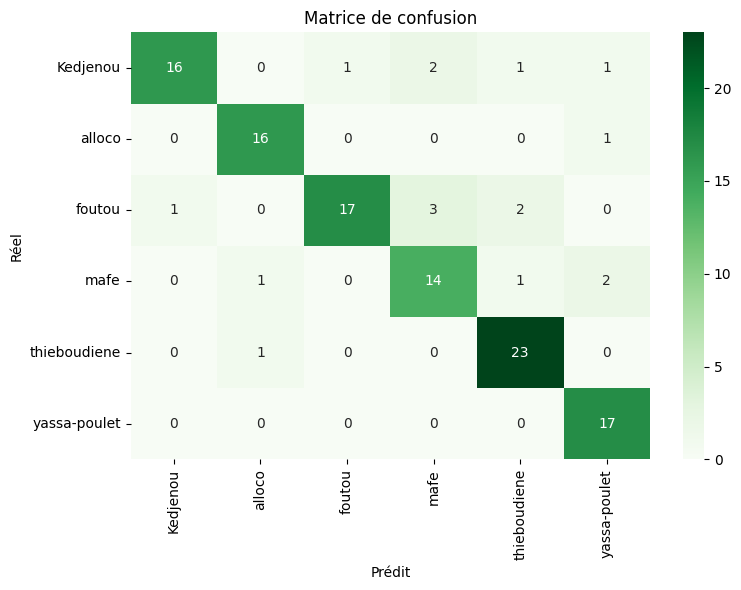


Rapport détaillé :
              precision    recall  f1-score   support

    Kedjenou       0.94      0.76      0.84        21
      alloco       0.89      0.94      0.91        17
      foutou       0.94      0.74      0.83        23
        mafe       0.74      0.78      0.76        18
thieboudiene       0.85      0.96      0.90        24
yassa-poulet       0.81      1.00      0.89        17

    accuracy                           0.86       120
   macro avg       0.86      0.86      0.86       120
weighted avg       0.87      0.86      0.86       120



In [18]:
# Matrice de confusion
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Prédictions sur la validation
y_pred = []
y_true = []

for images, labels in val_ds:
    preds = model_en.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# Matrice de confusion
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Greens")
plt.title("Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.savefig("matrice_confusion.png", dpi=150)
plt.show()

print("\nRapport détaillé :")
print(classification_report(y_true, y_pred, target_names=class_names))

In [19]:
# Sauvegarde du modèle
import os

# Créer le dossier models s'il n'existe pas
os.makedirs("models", exist_ok=True)

# Sauvegarder le modèle au format Keras
model_en.save("models/efficientnet_b0_phase1.keras")

print("Modèle sauvegardé dans models/efficientnet_b0_phase1.keras ✅")
print(f"Précision finale : {max(history.history['val_accuracy']):.2%}")

Modèle sauvegardé dans models/efficientnet_b0_phase1.keras ✅
Précision finale : 87.50%


In [20]:
# ============================================================
# MODÈLE 2 : MobileNetV2
# ============================================================

In [21]:
from tensorflow.keras.applications import MobileNetV2

In [25]:
 # Construction 
def build_mobilenet():
    preprocess_input = tf.keras.applications.mobilenet_v2.preprocess_input
 
    base_model_mn = MobileNetV2(
        weights='imagenet', include_top=False, input_shape=(*IMG_SIZE, 3)
    )
    base_model_mn.trainable = False
 
    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = data_augmentation(inputs)
    x = preprocess_input(x)
    x = base_model_mn(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
 
    model_mn = models.Model(inputs, outputs, name="MobileNetV2")
    return model_mn, base_model_mn
 
mobilenet_model, mobilenet_base = build_mobilenet()
mobilenet_model.summary()

Model: "MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_3 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_3 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [26]:
# Phase 1 : entraînement de la tête (backbone gelé)
mobilenet_model.compile(
               optimizer='adam', 
               loss='sparse_categorical_crossentropy', 
               metrics=['accuracy'])

history_mobilenet = mobilenet_model.fit(
   train_ds, validation_data=val_ds, epochs=20, callbacks=callbacks
)

Epoch 1/20


c:\Users\DELL\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


15/15 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.3833 - loss: 1.6312 - val_accuracy: 0.6250 - val_loss: 1.0416 - learning_rate: 0.0010
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step - accuracy: 0.6729 - loss: 0.9282 - val_accuracy: 0.7167 - val_loss: 0.7804 - learning_rate: 0.0010
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.7292 - loss: 0.7230 - val_accuracy: 0.7083 - val_loss: 0.6850 - learning_rate: 0.0010
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.7812 - loss: 0.6110 - val_accuracy: 0.7583 - val_loss: 0.5808 - learning_rate: 0.0010
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.8479 - loss: 0.4595 - val_accuracy: 0.8000 - val_loss: 0.5218 - learning_rate: 0.0010
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.8458 - loss: 0.4557 - val_accuracy: 0.8167 - val_loss: 0.5325 - learning_rate: 0.0010
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.8542 - loss: 0.4235 - val_accuracy: 0.7750 - va

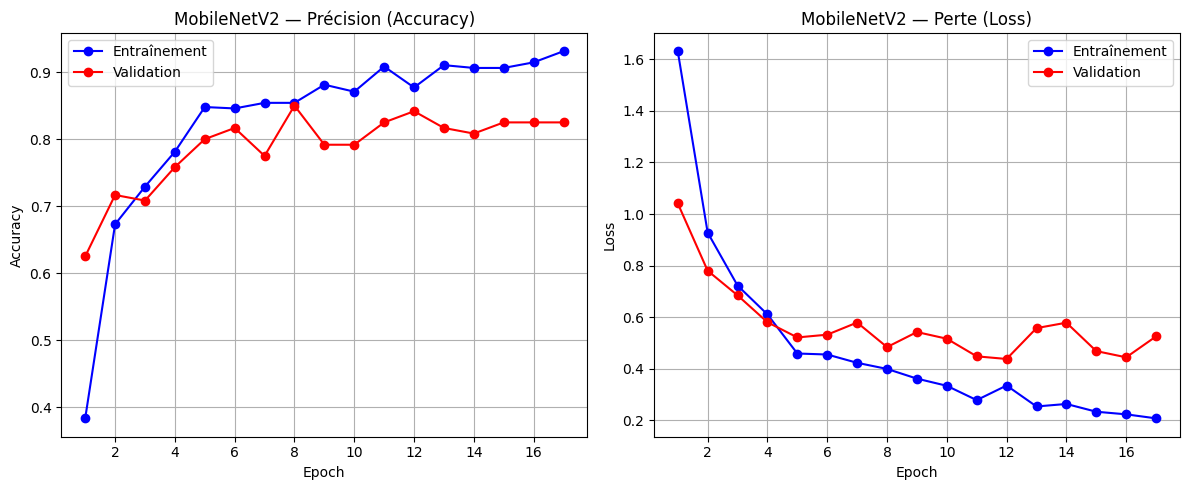

Courbes sauvegardées !


In [28]:
# Visualisation des courbes d'entraînement ---
import matplotlib.pyplot as plt
 
acc = history_mobilenet.history["accuracy"] 
val_acc = history_mobilenet.history["val_accuracy"] 
loss = history_mobilenet.history["loss"] 
val_loss = history_mobilenet.history["val_loss"]
epochs = range(1, len(acc) + 1)
 
plt.figure(figsize=(12, 5))
 
# Courbe Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, "b-o", label="Entraînement")
plt.plot(epochs, val_acc, "r-o", label="Validation")
plt.title("MobileNetV2 — Précision (Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
 
# Courbe Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, "b-o", label="Entraînement")
plt.plot(epochs, val_loss, "r-o", label="Validation")
plt.title("MobileNetV2 — Perte (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
 
plt.tight_layout()
plt.savefig("courbes_MobileNetV2.png", dpi=150)
plt.show()
print("Courbes sauvegardées !")

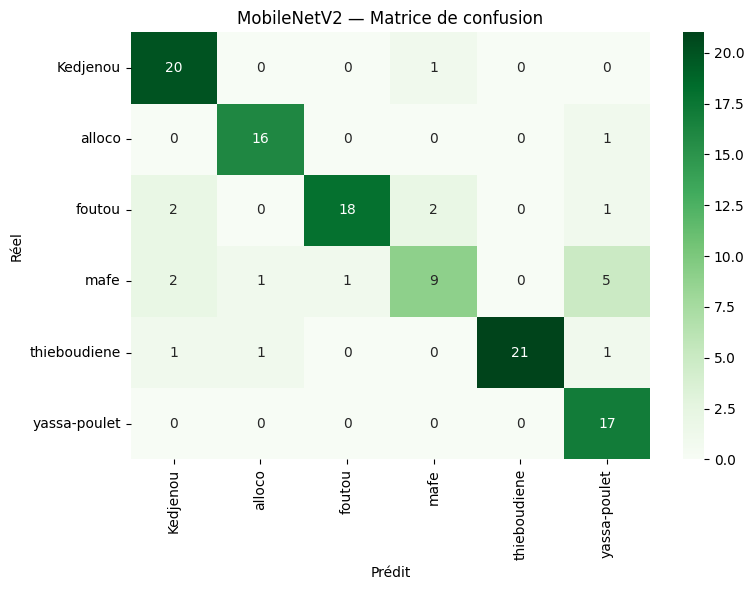


Rapport détaillé — MobileNetV2 :
              precision    recall  f1-score   support

    Kedjenou       0.94      0.76      0.84        21
      alloco       0.89      0.94      0.91        17
      foutou       0.94      0.74      0.83        23
        mafe       0.74      0.78      0.76        18
thieboudiene       0.85      0.96      0.90        24
yassa-poulet       0.81      1.00      0.89        17

    accuracy                           0.86       120
   macro avg       0.86      0.86      0.86       120
weighted avg       0.87      0.86      0.86       120



In [ ]:
# Matrice de confusion 
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
 
# Prédictions sur la validation
y_pred_mn = []
y_true_mn = []
 
for images, labels in val_ds:
    preds_mn = mobilenet_model.predict(images, verbose=0)
    y_pred_mn.extend(np.argmax(preds_mn, axis=1))
    y_true_mn.extend(labels.numpy())
 
# Matrice de confusion
cm = confusion_matrix(y_true_mn, y_pred_mn)
 
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cmap="Greens")
plt.title("MobileNetV2 — Matrice de confusion")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.savefig("matrice_confusion_MobileNetV2.png", dpi=150)
plt.show()
 
print("\nRapport détaillé — MobileNetV2 :")
print(classification_report(y_true, y_pred, target_names=class_names))
 

In [30]:
# Sauvegarde du modèle
 
# Création_du_dossier models 
os.makedirs("models", exist_ok=True)
 
# Sauvegarder le modèle au format Keras
mobilenet_model.save("models/mobilenetv2_final.keras")
 
print("Modèle sauvegardé dans models/mobilenetv2_final.keras ✅")
print(f"Précision finale : {max(val_acc):.2%}")

Modèle sauvegardé dans models/mobilenetv2_final.keras ✅
Précision finale : 85.00%
